[![Labellerr](https://storage.googleapis.com/labellerr-cdn/%200%20Labellerr%20template/notebook.webp)](https://www.labellerr.com)

# **Automated Surgical Equipment Segmentation**

---

[![labellerr](https://img.shields.io/badge/Labellerr-BLOG-black.svg)](https://www.labellerr.com/blog/<BLOG_NAME>)
[![Youtube](https://img.shields.io/badge/Labellerr-YouTube-b31b1b.svg)](https://www.youtube.com/@Labellerr)
[![Github](https://img.shields.io/badge/Labellerr-GitHub-green.svg)](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)

## Overview

This notebook demonstrates an **end-to-end computer vision pipeline** for **Automated Surgical Tool Identification and Segmentation** using **high-resolution 4K video**. The workflow utilizes a **fine-tuned YOLOv11 Nano Segmentation model** to precisely detect, classify, and segment 11 distinct types of surgical instruments (e.g., Scalpels, Forceps, Curettes) in highly complex medical environments.

---

## Real-World Applications

**Operating Room Safety (RSI)**  
Automated tracking to prevent Retained Surgical Items (sponges or tools left inside patients) by monitoring tool inventory before, during, and after surgery.

**Surgical Workflow Analysis**  
Tracking which tools are being used at what times to automatically document the phases of a surgical procedure.

**Automated Inventory Management**  
Real-time tracking of sterile trays to ensure all required instruments are present before a procedure begins.

**Surgical Skill Assessment**  
Analyzing how often and how smoothly specific tools are handled to assess trainee surgeon performance.

---

## Key Technical Features


**High-Definition Segmentation**  
Utilization of **Retina Masks** to ensure pixel-perfect boundaries on very thin, highly reflective metal instruments.

**Real-Time 4K Processing**  
Strategic use of the **YOLOv11 Nano (yolo11n-seg)** architecture to maintain incredibly high inference speeds on ultra-high-definition video without sacrificing precision.

**High Precision Classification**  
Achieved **96.5% Precision** across 11 complex classes of visually similar metallic tools.

---

## Annotate your Custom dataset using Labellerr

 ***1. Visit the [Labellerr](https://www.labellerr.com/?utm_source=githubY&utm_medium=social&utm_campaign=github_clicks) website and click **“Sign Up”**.*** 

 ***2. After signing in, create your workspace by entering a unique name.***

 ***3. Navigate to your workspace’s API keys page (e.g., `https://<your-workspace>.labellerr.com/workspace/api-keys`) to generate your **API Key** and **API Secret**.***

 ***4. Store the credentials securely, and then use them to initialise the SDK or API client with `api_key`, `api_secret`.***



## Setup Utilities
We start by cloning a utility repository that provides helper scripts for extracting frames from video and converting dataset formats.

In [1]:
!git clone https://github.com/Labellerr/yolo_finetune_utils.git

Cloning into 'yolo_finetune_utils'...


## Install Dependencies
Install the Ultralytics YOLO package along with necessary computer vision libraries like OpenCV and Matplotlib.

In [2]:
!pip install ultralytics opencv-python matplotlib cv2

ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for cv2


## Data Preparation: Frame Extraction
To create our training dataset, we extract random frames from our high-resolution 4K surgical video.

In [ ]:
from yolo_finetune_utils.frame_extractor import extract_random_frames

extract_random_frames(
    paths=['7585005-uhd_4096_2160_25fps.mp4'],
    total_images=100,
    out_dir="datasetFrames",
    jpg_quality=100,
    seed=42
)

[✓] Extracted 7 frames to folder: datasetFrames


## Format Conversion (COCO to YOLO)
The extracted frames were labeled and exported in COCO JSON format. YOLO requires a specific folder structure (`images/train`, `labels/train`, etc.). We use the `coco_to_yolo_converter` to parse the JSON and split our data into training and validation sets.

In [ ]:
# Import the converter utility
from yolo_finetune_utils.coco_yolo_converter.seg_converter import coco_to_yolo_converter

# Execute the conversion
coco_to_yolo_converter(
    json_path="8e300830-554f-45d2-a58c-2258dd029127.json",              # Your COCO file
    images_dir="datasetframes",    # Where your 20 tiled images are
    output_dir="dataprocessed",                 # This will create 'labels' folder automatically
    use_split=True,                              # Split into Train/Val/Test
    train_ratio=0.8,
    val_ratio=0.1,                               # Increased for small dataset
    test_ratio=0.1,                              # Set to 0 since we only have 20 images
    shuffle=True,
    verbose=True
)

Conversion complete. Stats: {'train': 5, 'val': 1, 'test': 1}


{'stats': {'train': 5, 'val': 1, 'test': 1}, 'output_dir': 'dataprocessed'}

# Load and Train YOLO Segmentation Model

Loads the YOLO segmentation model and trains it using the converted YOLO dataset.
- Data: Path to YOLO-style `data.yaml`
- Parameters: epochs, image size, batch size, device, dataloader workers, experiment name.


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n-seg.pt") 

model.train(
    data="dataprocessed\data.yaml",
    epochs=100,        # Still need this to train long enough
    freeze=10,         # Still critical to protect pre-trained weights
    imgsz=640,
    patience=50,
    # Kept to prevent memorizing the background:
    mosaic=1.0,      
    hsv_h=0.015,     # Helps if lighting flickers in the video
    
    # Removed because you are testing on the exact same static video:
    mixup=0.0,
    degrees=0.0,    
    flipud=0.0,      
    fliplr=0.0,      
    scale=0.0        
)


## Run Inference on Video
Finally, we load our best trained weights and run inference back on the original surgical video. 

We lower the confidence threshold slightly (`conf=0.2`) to account for the small dataset, and we set `line_width=2` to ensure the text labels are readable while keeping the bounding boxes relatively thin.

![Inference Output](attachment:Screenshot%202026-08-26%20223932.png)
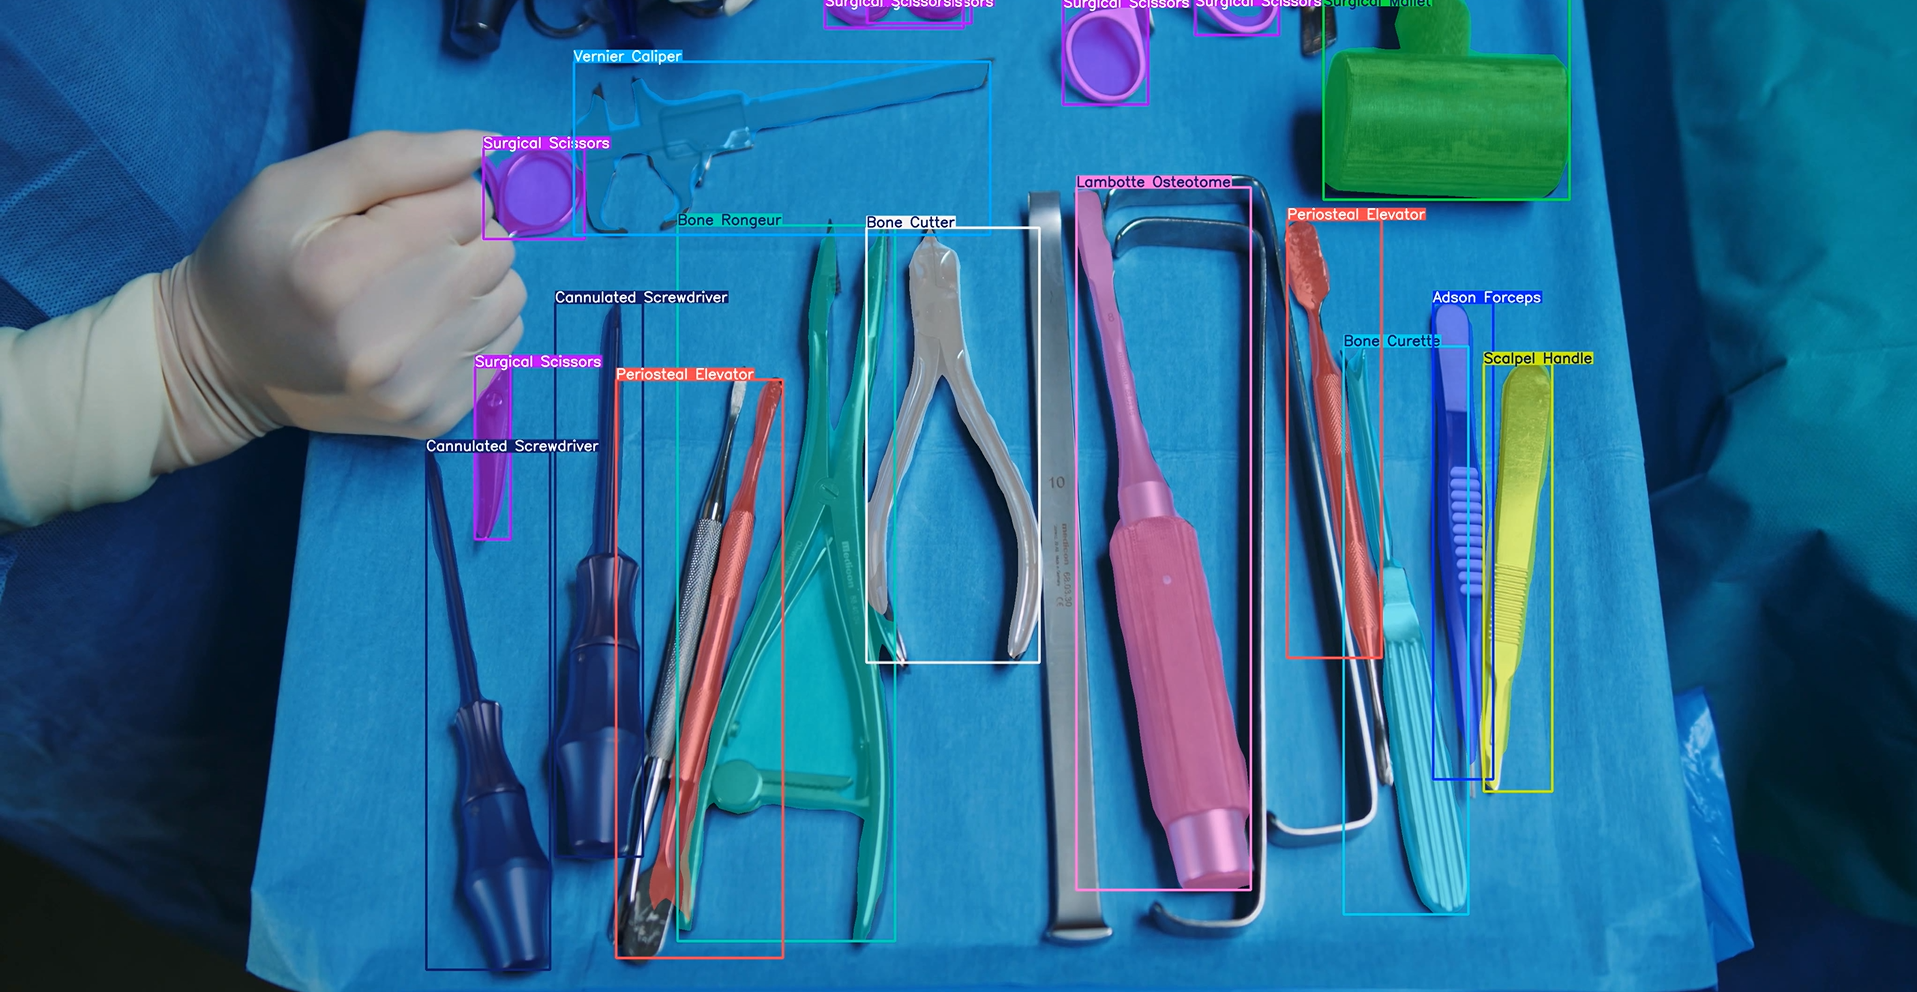

In [ ]:
from ultralytics import YOLO

# 1. Load your best trained model for surgical equipment
model = YOLO('runs/segment/train/weights/best.pt')

# 2. Use the local surgical video for inference
video_path = '7585005-uhd_4096_2160_25fps.mp4'

# 3. Run inference with all "Detection UI" elements removed (clean masks only)
results = model.predict(
    source=video_path,
    save=True,
    conf=0.2,
    imgsz=640,
    retina_masks=True,  # Keeps boundaries sharp for surgical tools
    show_boxes=True,   # Removes the rectangles
    show_conf=False,    # Removes the confidence percentages (0.85, etc.)
    show_labels=True,   # Keeps only the names (Scalpel Handle, Forceps, etc.)
    project='runs/segment',
    name='surgical_equipment_output'
)

print("✅ Professional Surgical Equipment inference complete. Clean masks saved.")


---

## 👨‍💻 About Labellerr's Hands-On Learning in Computer Vision

Thank you for exploring this **Labellerr Hands-On Computer Vision Cookbook**! We hope this notebook helped you learn, prototype, and accelerate your vision projects.  
Labellerr provides ready-to-run Jupyter/Colab notebooks for the latest models and real-world use cases in computer vision, AI agents, and data annotation.

---
## 🧑‍🔬 Check Our Popular Youtube Videos

Whether you're a beginner or a practitioner, our hands-on training videos are perfect for learning custom model building, computer vision techniques, and applied AI:

- [How to Fine-Tune YOLO on Custom Dataset](https://www.youtube.com/watch?v=pBLWOe01QXU)  
  Step-by-step guide to fine-tuning YOLO for real-world use—environment setup, annotation, training, validation, and inference.
- [Build a Real-Time Intrusion Detection System with YOLO](https://www.youtube.com/watch?v=kwQeokYDVcE)  
  Create an AI-powered system to detect intruders in real time using YOLO and computer vision.
- [Finding Athlete Speed Using YOLO](https://www.youtube.com/watch?v=txW0CQe_pw0)  
  Estimate real-time speed of athletes for sports analytics.
- [Object Counting Using AI](https://www.youtube.com/watch?v=smsjBBQcIUQ)  
  Learn dataset curation, annotation, and training for robust object counting AI applications.
---

## 🎦 Popular Labellerr YouTube Videos

Level up your skills and see video walkthroughs of these tools and notebooks on the  
[Labellerr YouTube Channel](https://www.youtube.com/@Labellerr/videos):

- [How I Fixed My Biggest Annotation Nightmare with Labellerr](https://www.youtube.com/watch?v=hlcFdiuz_HI) – Solving complex annotation for ML engineers.
- [Explore Your Dataset with Labellerr's AI](https://www.youtube.com/watch?v=LdbRXYWVyN0) – Auto-tagging, object counting, image descriptions, and dataset exploration.
- [Boost AI Image Annotation 10X with Labellerr's CLIP Mode](https://www.youtube.com/watch?v=pY_o4EvYMz8) – Refine annotations with precision using CLIP mode.
- [Boost Data Annotation Accuracy and Efficiency with Active Learning](https://www.youtube.com/watch?v=lAYu-ewIhTE) – Speed up your annotation workflow using Active Learning.

> 👉 **Subscribe** for Labellerr's deep learning, annotation, and AI tutorials, or watch videos directly alongside notebooks!

---

## 🤝 Stay Connected

- **Website:** [https://www.labellerr.com/](https://www.labellerr.com/)
- **Blog:** [https://www.labellerr.com/blog/](https://www.labellerr.com/blog/)
- **GitHub:** [Labellerr/Hands-On-Learning-in-Computer-Vision](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)
- **LinkedIn:** [Labellerr](https://in.linkedin.com/company/labellerr)
- **Twitter/X:** [@Labellerr1](https://x.com/Labellerr1)

*Happy learning and building with Labellerr!*
